# Amazon India Sales Data Analytics Notebook
This notebook presents an interactive, step-by-step data analysis pipeline for Amazon India's transactional sales data. It walks through data loading, comprehensive data validation, cleaning/enrichment, key performance indicator (KPI) calculations, category-level performance assessments, temporal trends, and correlation tables.

## Project Structure Check
Ensure that the `src` directory is on the path to import our modular cleaning utilities.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to system path
sys.path.append(os.path.abspath('../src'))
from utils import load_data, validate_data, clean_data
from dashboard import (
    plot_sales_by_state, 
    plot_sales_by_category, 
    plot_monthly_trend, 
    plot_sales_by_subcategory
)

# Notebook styling
sns.set_theme(style="whitegrid")
%matplotlib inline


### Q1 & Q2: Dataset Loading and Validation
We load the raw dataset, run standard validation checks (checking for missing values, duplicates, and negative numbers), and clean/enrich the dataset with:
1. **Sub-Category**: A mapped categorisation derived from the 50 unique product names.
2. **Profit**: Dynamic margin calculation reflecting discounts, manufacturing costs, and order statuses (penalising returns with negative profit).


In [2]:
raw_path = "../data/Amazon_Sales.xlsx"
df_raw = load_data(raw_path)

print("\n--- Validation Report ---")
report = validate_data(df_raw)
for key, val in report.items():
    print(f"{key}: {val}")

print("\n--- Cleaning Data ---")
df_clean = clean_data(df_raw)
print("Cleaned Data Shape:", df_clean.shape)
df_clean.head(2)


2026-06-28 20:01:15,645 [INFO] Attempting to load dataset from: ../data/Amazon_Sales.xlsx


2026-06-28 20:01:25,039 [INFO] Successfully loaded dataset of shape (100000, 20) in 9.39 seconds.



--- Validation Report ---
2026-06-28 20:01:25,040 [INFO] Starting data validation...


2026-06-28 20:01:25,068 [INFO] Missing values found: {}


2026-06-28 20:01:25,159 [INFO] Duplicate rows count: 0


...

2026-06-28 20:01:25,378 [INFO] Mapping Sub-Categories based on product list...


2026-06-28 20:01:25,385 [INFO] Calculating derived Profit column...


2026-06-28 20:01:25,399 [INFO] Data cleaning and enrichment complete.


Cleaned Data Shape: (100000, 22)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,SubCategory,Profit
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,Drones & Robotics,95.93
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,Audio Accessories,57.82


### Q3: Key Performance Indicators (KPIs)
Here, we compute the primary corporate health metrics:
* **Total Sales (GMV)**
* **Total Profit**
* **Total Transactions**
* **Average Order Value (AOV)**
* **Gross Profit Margin (%)**


In [3]:
total_sales = df_clean['TotalAmount'].sum()
total_profit = df_clean['Profit'].sum()
total_orders = df_clean['OrderID'].nunique()
avg_sales = df_clean['TotalAmount'].mean()
avg_profit = df_clean['Profit'].mean()
aov = total_sales / total_orders
gross_margin = (total_profit / total_sales) * 100

print(f"Total Sales (GMV): ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Sales per Order: ₹{avg_sales:,.2f}")
print(f"Average Profit per Order: ₹{avg_profit:,.2f}")
print(f"Average Order Value (AOV): ₹{aov:,.2f}")
print(f"Gross Profit Margin: {gross_margin:.2f}%")


Total Sales (GMV): ₹91,825,647.92
Total Profit: ₹16,210,439.18
Total Orders: 100,000
Average Sales per Order: ₹918.26
Average Profit per Order: ₹162.10
Average Order Value (AOV): ₹918.26
Gross Profit Margin: 17.65%


### Q4: Sales by State
Analysis of geographic performance. Let's see the top 10 states by sales.


In [4]:
state_sales = df_clean.groupby('State').agg(
    Total_Sales=('TotalAmount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('OrderID', 'count')
).sort_values(by='Total_Sales', ascending=False).head(10)
state_sales


,Total_Sales,Total_Profit,Order_Count
State,,,
TX,22862540.54,4065233.35,24896
CA,18231196.79,3210395.09,19921
NC,4747701.73,848081.85,5110
WA,4660962.17,802851.48,5039
PA,4650673.88,835524.86,5014
CO,4638498.97,815980.38,4991
IL,4632847.44,816560.53,5020
OH,4615442.32,825584.07,5021
IN,4609048.43,811674.64,4970


### Q5: Sales by Category
We evaluate the performance of primary categories to see which ones are top drivers and which ones have the healthiest profit margins.


In [5]:
cat_sales = df_clean.groupby('Category').agg(
    Total_Sales=('TotalAmount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('OrderID', 'count')
).sort_values(by='Total_Sales', ascending=False)
cat_sales['Margin_%'] = (cat_sales['Total_Profit'] / cat_sales['Total_Sales']) * 100
cat_sales


,Total_Sales,Total_Profit,Order_Count,Margin_%
Category,,,,
Electronics,15584217.18,1074678.14,16853,6.895939
Sports & Outdoors,15345571.88,2055026.73,16804,13.391659
Books,15261837.01,3171878.16,16752,20.783069
Clothing,15253397.50,4600105.98,16439,30.157911
Toys & Games,15216684.99,2457595.56,16542,16.150663
Home & Kitchen,15163939.36,2851154.61,16610,18.802203


### Q7: Sales by Sub-Category
We drill down into the 15 product sub-categories to isolate sales drivers.


In [6]:
subcat_sales = df_clean.groupby('SubCategory').agg(
    Total_Sales=('TotalAmount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('OrderID', 'count')
).sort_values(by='Total_Sales', ascending=False)
subcat_sales['Margin_%'] = (subcat_sales['Total_Profit'] / subcat_sales['Total_Sales']) * 100
subcat_sales


,Total_Sales,Total_Profit,Order_Count,Margin_%
SubCategory,,,,
Audio Accessories,7390413.59,1312928.84,7986,17.765296
Apparel,7373265.74,1305349.38,7908,17.703816
Power Accessories,7150238.03,1250825.28,7875,17.493477
Data Storage,5540624.11,965215.95,6044,17.420708
Kitchen Appliances,5534318.25,977051.42,6077,17.654413
Computer Input,3802067.52,666053.52,4044,17.518193
Home Lighting,3790888.99,654628.65,4134,17.268473
Mobile Accessories,3741677.72,662929.56,3985,17.717441
Wearables,3685425.09,650243.38,3932,17.643647


### Q9: Top Customers
We identify the top 10 high-value customers by their lifetime purchases and check their loyalty and transactional count.


In [7]:
top_customers = df_clean.groupby(['CustomerID', 'CustomerName']).agg(
    Total_Spent=('TotalAmount', 'sum'),
    Total_Profit_Gen=('Profit', 'sum'),
    Order_Count=('OrderID', 'count'),
    Avg_Order_Value=('TotalAmount', 'mean')
).sort_values(by='Total_Spent', ascending=False).head(10)
top_customers


,,Total_Spent,Total_Profit_Gen,Order_Count,Avg_Order_Value
CustomerID,CustomerName,,,,
CUST010696,Pooja Patel,5436.04,1253.52,2,2718.020
CUST035973,Neha Sharma,5124.43,924.97,2,2562.215
CUST009614,Vikas Mehta,5003.65,1016.46,2,2501.825
CUST018720,Arjun Kapoor,4773.18,576.03,2,2386.590
CUST022824,Pooja Joshi,4755.48,827.17,2,2377.740
CUST008882,Sneha Reddy,4730.47,1176.16,2,2365.235
CUST022031,Priya Kapoor,4266.02,705.23,2,2133.010
CUST031449,Vivaan Kapoor,4253.27,1136.91,2,2126.635
CUST005523,Sahil Patel,4239.18,1037.63,2,2119.590


### Q10: Product Quantity
Isolation of the top 10 products sold by units/quantity.


In [8]:
top_products = df_clean.groupby(['ProductID', 'ProductName']).agg(
    Total_Qty_Sold=('Quantity', 'sum'),
    Total_Revenue=('TotalAmount', 'sum'),
    Avg_Unit_Price=('UnitPrice', 'mean')
).sort_values(by='Total_Qty_Sold', ascending=False).head(10)
top_products


,,Total_Qty_Sold,Total_Revenue,Avg_Unit_Price
ProductID,ProductName,,,
P00019,LED Desk Lamp,6344,1921948.41,298.772264
P00022,Water Bottle,6275,1895467.95,300.156882
P00047,Memory Card 128GB,6240,1935138.40,307.712050
P00037,Router,6202,1850756.20,295.288608
P00032,Board Game,6200,1863310.96,297.802565
P00040,Microphone,6196,1871740.68,301.671008
P00006,Gaming Mouse,6170,1895103.98,303.370169
P00017,Electric Kettle,6165,1905751.79,304.352201
P00007,Mechanical Keyboard,6161,1906963.54,306.598461


### Q11: Payment Method Preferences
Analysis of checkout payment choices and their correlation to average transaction amounts.


In [9]:
pay_methods = df_clean.groupby('PaymentMethod').agg(
    Total_Sales=('TotalAmount', 'sum'),
    Order_Count=('OrderID', 'count'),
    Avg_Sales=('TotalAmount', 'mean')
).sort_values(by='Total_Sales', ascending=False)
pay_methods['Sales_Share_%'] = (pay_methods['Total_Sales'] / total_sales) * 100
pay_methods['Order_Share_%'] = (pay_methods['Order_Count'] / total_orders) * 100
pay_methods


,Total_Sales,Order_Count,Avg_Sales,Sales_Share_%,Order_Share_%
PaymentMethod,,,,,
Credit Card,32122158.69,35038,916.780601,34.981685,35.038
Debit Card,18538678.53,20024,925.822939,20.188998,20.024
UPI,13896028.55,15066,922.343592,15.133058,15.066
Amazon Pay,13697498.42,15017,912.132811,14.916855,15.017
Net Banking,9055674.57,9927,912.226712,9.861814,9.927
Cash on Delivery,4515609.16,4928,916.316794,4.917590,4.928


### Q12: Monthly Sales and Profit Trend
Aggregating transactions monthly to understand trends, seasonality, and overall performance trajectories.


In [10]:
df_clean['YearMonth'] = df_clean['OrderDate'].dt.to_period('M')
monthly_data = df_clean.groupby('YearMonth').agg(
    Monthly_Sales=('TotalAmount', 'sum'),
    Monthly_Profit=('Profit', 'sum'),
    Order_Count=('OrderID', 'count')
).reset_index()
monthly_data['YearMonth_Str'] = monthly_data['YearMonth'].astype(str)

print("First Year Monthly Preview:")
display(monthly_data.head(12))


First Year Monthly Preview:


,YearMonth,Monthly_Sales,Monthly_Profit,Order_Count,YearMonth_Str
0,2020-01,1637069.40,286075.03,1730,2020-01
1,2020-02,1339388.21,244942.76,1490,2020-02
2,2020-03,1587125.66,272179.04,1685,2020-03
3,2020-04,1588347.29,281621.40,1692,2020-04
4,2020-05,1533834.17,273980.74,1672,2020-05
5,2020-06,1500269.29,267081.62,1633,2020-06
6,2020-07,1552981.94,273069.20,1687,2020-07
7,2020-08,1640874.93,288407.39,1783,2020-08
8,2020-09,1554682.21,282805.75,1679,2020-09
9,2020-10,1515403.62,269894.24,1647,2020-10


### Q13: Multi-Level Analysis (Cross-tabulations)
We evaluate structural combinations like:
1. Category by Country sales.
2. Payment Method by Order Status counts (revealing reverse logistics leakages for different modes).


In [11]:
print("--- Category by Country Sales ---")
display(pd.crosstab(df_clean['Category'], df_clean['Country'], values=df_clean['TotalAmount'], aggfunc='sum'))

print("\n--- Payment Method by Order Status Counts ---")
display(pd.crosstab(df_clean['PaymentMethod'], df_clean['OrderStatus']))

print("\n--- Status Distribution Rates (%) by Payment Method ---")
display(pd.crosstab(df_clean['PaymentMethod'], df_clean['OrderStatus'], normalize='index') * 100)


--- Category by Country Sales ---


Country,Australia,Canada,India,United Kingdom,United States
Category,,,,,
Books,667207.38,869795.13,2317323.78,739591.95,10667918.77
Clothing,655355.03,834578.61,2287571.02,798338.82,10677554.02
Electronics,656006.46,920603.04,2345341.29,772226.12,10890040.27
Home & Kitchen,553604.52,911373.57,2257654.08,741753.78,10699553.41
Sports & Outdoors,638811.05,889160.64,2345959.71,748644.58,10722995.90
Toys & Games,618122.00,898246.01,2321989.24,726341.61,10651986.13



--- Payment Method by Order Status Counts ---


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Amazon Pay,461,11251,585,472,2248
Cash on Delivery,156,3633,196,143,800
Credit Card,1083,26073,1471,1075,5336
Debit Card,593,14917,832,609,3073
Net Banking,291,7406,417,313,1500
UPI,444,11348,602,437,2235



--- Status Distribution Rates (%) by Payment Method ---


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Amazon Pay,3.069854,74.921755,3.895585,3.143104,14.969701
Cash on Delivery,3.165584,73.721591,3.977273,2.901786,16.233766
Credit Card,3.090930,74.413494,4.198299,3.068097,15.229180
Debit Card,2.961446,74.495605,4.155014,3.041350,15.346584
Net Banking,2.931399,74.604614,4.200665,3.153017,15.110305
UPI,2.947033,75.321917,3.995752,2.900571,14.834727


### Q15 - Q18: Visualizations
We generate and display the analytical charts within the notebook cells.


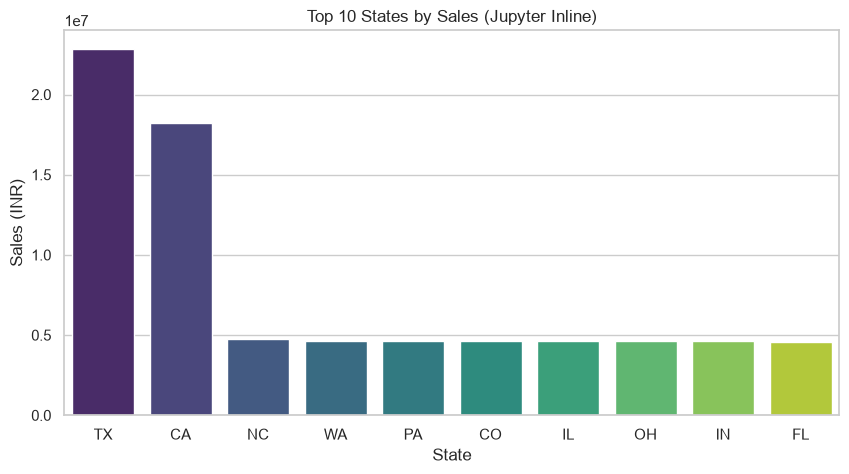

In [12]:
# Q15: Top States by Sales
state_plot_data = df_clean.groupby('State')['TotalAmount'].sum().reset_index().sort_values(by='TotalAmount', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='State', y='TotalAmount', data=state_plot_data, palette='viridis', hue='State', legend=False)
plt.title("Top 10 States by Sales (Jupyter Inline)")
plt.ylabel("Sales (INR)")
plt.show()


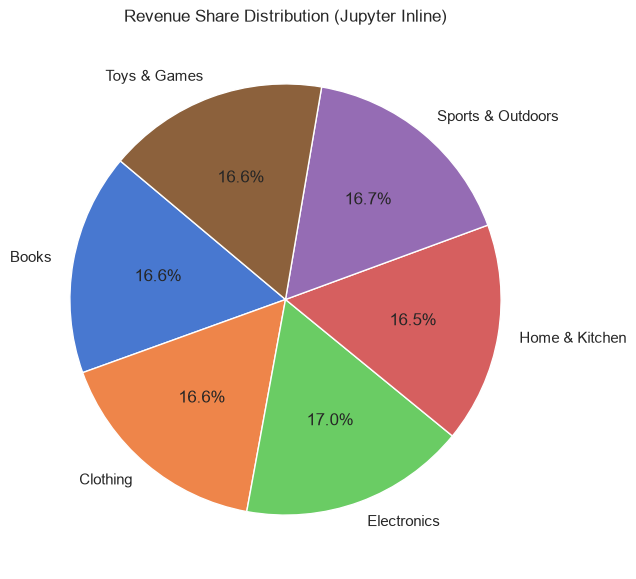

In [13]:
# Q16: Sales share by Category
cat_plot_data = df_clean.groupby('Category')['TotalAmount'].sum()
plt.figure(figsize=(7, 7))
plt.pie(cat_plot_data, labels=cat_plot_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("muted"))
plt.title("Revenue Share Distribution (Jupyter Inline)")
plt.show()


2026-06-28 20:01:25,902 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-28 20:01:25,904 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-28 20:01:25,906 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-28 20:01:25,907 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-28 20:01:25,908 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


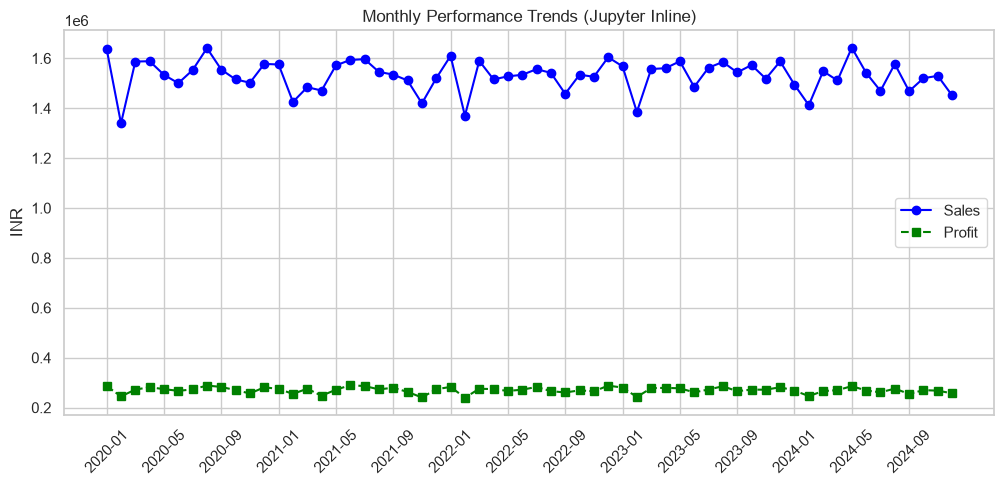

In [14]:
# Q17: Monthly Trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_data['YearMonth_Str'], monthly_data['Monthly_Sales'], label='Sales', color='blue', marker='o')
plt.plot(monthly_data['YearMonth_Str'], monthly_data['Monthly_Profit'], label='Profit', color='green', marker='s', linestyle='--')
plt.xticks(monthly_data['YearMonth_Str'].values[::4], rotation=45)
plt.title("Monthly Performance Trends (Jupyter Inline)")
plt.ylabel("INR")
plt.legend()
plt.show()


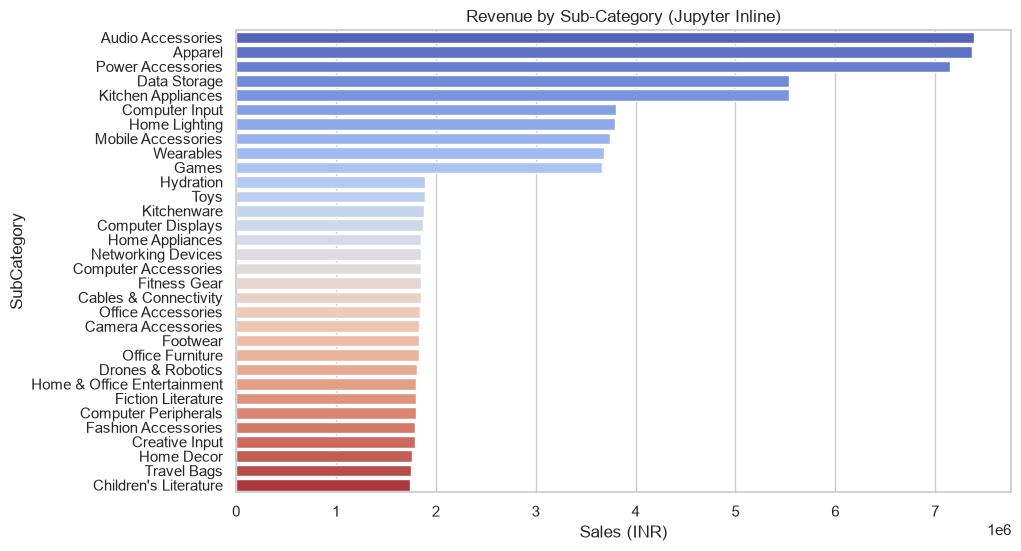

In [15]:
# Q18: Sales by Sub-Category
sub_plot_data = df_clean.groupby('SubCategory')['TotalAmount'].sum().reset_index().sort_values(by='TotalAmount', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(y='SubCategory', x='TotalAmount', data=sub_plot_data, palette='coolwarm', hue='SubCategory', legend=False)
plt.title("Revenue by Sub-Category (Jupyter Inline)")
plt.xlabel("Sales (INR)")
plt.show()
